# Strategic University Admissions Report

This report summarizes our project on strategic university admissions with multi-class classification.

## Motivation

In this project, we explore a more complex version of the strategic loan applicants problem than what was presented in class section 5. The traditional strategic setting involves a binary decision (accept/reject) where applicants try to game the system to be accepted, and the classifier tries to avoid being gamed.

Our approach extends this framework by changing the binay scenario to a multi-class scenario: Instead of a binary accept/reject decision, we implement a university admissions system with multiple faculties. Each faculty has different preferences over student features, represented as utility vectors. In this this way, there is no "right" or "wrong" decision, but rather a decision that is better or worse for the applicant. This makes it more interesting, as the university can no longer know the objective of the applicant, and so it is harder to try and predict the applicant's behavior and modifications.


## Research 

While previous work has focused on strategic behavior in binary classification settings (e.g., loan approvals where applicants try to game the system to get accepted), our work extends this to multi-class classification scenarios. Specifically, we explore:

How do strategic behaviors manifest differently when agents (students) are trying to influence a multi-class classifier (university faculty assignments) compared to binary classifiers, and what mechanisms can institutions employ to maintain system effectiveness?

Key differences in our setting:
1. Instead of a simple accept/reject outcome, students aim for specific faculties
2. The "optimal" outcome is subjective - different students prefer different faculties
3. The institution (university) can't easily determine if gaming occurred since student preferences are legitimate
4. Success metrics must balance both student satisfaction (getting desired faculty) and system effectiveness (grades)



#### **Our research question is: Is there a sweet spot for the university to balance student satisfaction and system effectiveness by strategically choosing which data to expose to the applicants and/or by strategically choosing which data to use for the faculty assignment?**

## Players

Our economic system includes three key players with different objectives:

### The University
- **Objective**: Maximize the mean grades of students assigned to faculties
- **Tools**: Assigns students to faculties based on their features, and what it predicts will net them the highest grade
- **Strategic Considerations**: Prediction isn't Recommendation, and so the university must consider the strategic behavior of the applicants. The grade will be a function of the faculty's utility vector and the applicant's **original** features, while it might be presented with the applicant's **modified** features.
- **Optional Role**: Can act as a supplier in some scenarios, guaranteeing admission to desired faculty for qualified students

### The Applicants
- **Objective**: Get assigned to their desired faculty
- **Tools**: Can choose a supplier to modify their features. The supplier will modify their features in a predetermined way, and so the applicant must choose the supplier that will best help them achieve their goal. 
- **Strategic Considerations**: Must choose which supplier will best help them achieve their goal
- **Information Access**: May have varying levels of knowledge about their own features, the university's model, or past outcomes, based on the scenario

### The Suppliers
- **Objective**: Be selected by applicants (implicitly maximizing revenue)
- **Tools**: Each supplier has a specific "modification vector" that alters student features in predetermined ways
- **Limitations**: Cannot create custom modifications for each student; have fixed patterns of feature changes


## Modulation

The project implements the strategic admissions scenario through a modular code structure in the following ways

### The Role of the Environment

Our environment serves as the simulation engine that creates the dynamic interactions between applicants, suppliers, and the university (main players).

It is designed to:
- Generate synthetic datasets representing diverse applicants (with different skills and grades)
- Model the university’s hidden criteria within different faculties (with different requirements).
- Represent how third-party suppliers in a meaningful way (so they can impact results)
- Provide a controlled yet flexible space for experimenting with different strategic scenarios.

The environment leverages vector-based representations of the key players, allowing for efficient calculations of outcomes.


### UniversityMLP

#### Purpose
The model serves as university's decision-making - predicting *final grades* for each faculty given an applicant's feature vector.
#### Main Components:
- Works with the number of features and faculties
- **Feed-Forward MLP** - outputs the predicted final grades for all faculties.

The Model learn the nonlinear relationships between features and success across faculties.


### ApplicantMLP

#### Purpose
Allows applicants to learn and predict **which faculty they’re most likely to be assigned based on their (possibly manipulated) features**.
#### Main Parameters and Components:
- Works with the number of features and faculties
- **Feed-Forward MLP** - outputs the predicted final grades for all faculties.
- **Softmax output** - Produces a probability distribution over faculties.

The Model is used by the applicant to quantify the impact of supplier modifications on the likelihood of achieving the desired outcome.



### Environment Params
#### FacultyParams
- Represents the hidden success criteria of each faculty. 
- Each Faculty has *utility vectors* with weights indicating the importance of each feature gore the faculty.
- weights are normalize and randomly assigned
- **Goal** -  to be as realitic as possible while being diverse enough to create seperation between faculties

#### SupplierParams
- Represents hird-party suppliers offering feature modifications to applicants.
- Each Supplier has *diff vectors* with (partial) modification weights for boosting or negating specific features.
- **Goal** - to mimic supplier behavior in real life while being effective enough to effect the decision making process.

### UniversityEnvironment 
#### Purpose 
Acts as the simulation manager — creating faculties, suppliers, applicants, and running the mechanics of the game.

#### Main Design Ideas 
- control the Number of applicant features, university faculties and third-party suppliers (including uni-supplier).
- Maneges the complexity (deciding how many features and noise are added) and size (how many applicants, suppliers and faculties are included) of the system.
- Mimicing real-world mechanisms to try to model realistic scenarios (focusing of critical features/scores per faculty, creating trade-offs for suppliers, adding noise between expectation and actual results) 

#### DF Generations 
- Creates historical data for training ML models (cold start data frames). These past applicants serves at the applicants for the university to use and for the applicants to learn from (mimic how future applicants learn by past student what it's best to focus on for getting to the desired faculty). **Goal** - Simulate a real-world dataset of past university decisions.
- Create current applicants DF (stratigic students). **Goal** - Provide a testbed for current strategies, manipulation, and experiments.
- all student are assigned with desired faculty randomly - for diverse faculty desires.

## Base Scenario

The base scenario in our simulation is the "Modified with Feature Knowledge" scenario. Here's how it works:

### Initial Setup - No training (Iteration -1)
1. A university environment is created with multiple faculties, each with its own utility vector.
2. Multiple suppliers are created, each with a predetermined modification vector.
3. We generate a set of applicants, each with natural features, an assigned faculty, and a final grade.

### Iteration 0: University training
1. The university trains its admission model on the past data (Iteration -1), learning to predict which faculty would best suit each student.
2. We generate a set of applicants, each with natural features
3. The university assigns each applicant to a faculty based on their features, and calculates the final grade for each applicant.

### Iteration 1: Strategic Behavior
1. The applicant model is trained on the past data (Iteration 0), learning to predict which faculty they'll be assigned to based on their features.
2. A new set of applicants is generated, each with natural features and a desired faculty.
3. Each applicant then selects a supplier that maximizes their chance of being assigned to their desired faculty, The key aspect of the base scenario is that students have knowledge of their original features.
4. The university then assigns students to faculties based on their **modified** features after the supplier's modifications.
5. A final grade is calculated based on the the applicant's **original** features and the faculty's utility vector of the faculty they were assigned to.

### Outcome metrics:
- Percentage of students that got their desired faculty
- Mean grade


### Scenario Variations

After establishing the base scenario of **"Modified with Feature Knowledge"**, we explored several variations. Each variation models a different strategic scenario or changes in information dynamics, designed to test the robustness of the university system under varying degrees of manipulation and knowledge.

For each variation, we will show the core changes from the base scenario, the intuition behind it, and the key evaluation metrics. We will mainly focus on two Evaluation Metrics **total mean grades and percentage of students assigned to their desired faculty**.

#### 1. Modified Without Feature Knowledge

##### Description:
In this scenario, applicants do **not** have access to their true feature vector. Instead, thier choice is soppused to represent desicions that rely on general knowledge or assumptions when choosing a supplier. Key Changes include applicants choosing suppliers **do not know their own feature vector**. In Additions, supplier impact is less predictable, possibly leading to mismatches or inefficient manipulation.

##### Expected Impact:
- **General sinilar or even lower percentage of students** achieving their desired faculty compared to the base. this based on the fact that Without knowledge of their own strengths/weaknesses, students cannot select the supplier that truly helps with their desired faculty. There is no proven way for them to improve their abilities.
- Potentially **lower mean grades**, as manipulation is less precise (even though the loss of mean grade will be small and accour only on the rare cases were students accually changed thier faculties, even if not to the desired one).

##### Code Modifications:
- Applicants select suppliers **without access to their own features** by setting `use_feature_knowledge=False` during supplier selection. instead we use base vector (generic for all students) and try to find the modification that potentially can benefit the students (supplier that seems most effective)
- **Feature-blending logic was introduced**: When applicants lack knowledge of their own features, the supplier’s modification is blended carefully with the original features. Specifically, **only the modified feature indices** from the supplier are applied, while all unmodified features default to the applicant’s original values.


#### 2. Fully Exposed Supplier Scenario

##### Description:
In this scenario, suppliers are given **full access to the university model**, allowing them to perfectly optimize their modifications based on exactly how the university predicts grades.
Suppliers simulate the effect of every possible modification and choose the one that **maximizes the university's predicted grade for the applicant's desired faculty**.

##### Expected Impact:
- We beilive this scenario will allow the hightest precentage of student to reach thier desired faculty because the suppliers now exploit the exact logic of the university model - which allow the students to know in advance if and how they can get their desired faculty.
- **Lower mean grades**, as suppliers are able to manipulate the university into making the most suboptimal assignments based on inflated or targeted feature changes.
- This scenario demonstrates the dangers of full system transparency in a strategic environment, where external agents can reverse-engineer the system and, as a result, lowering the system success too much.

##### Code Modifications:
- Supplier selection logic changes to **simulate the university model predictions for every supplier's modification**.
- Suppliers choose the modification that **maximizes the university’s predicted grade** for the student’s desired faculty using `choose_supplier_for_applicant_fully_exposed()`.#

#### 3. University Reconstruction Scenario

##### Description:
In this scenario, the university **actively tries to reverse supplier manipulation** by reconstructing the original applicant feature vectors before making faculty assignment decisions. 
The university uses group-based proportional adjustments based on applicant groups with the same desired faculty to estimate the unmodified features.

##### Expected Impact:
- **Higher mean grades** because the university is better able to match students based on their real abilities rather than manipulated features (even if this method will not achive the result of the original, no-gaming, option)
- **Reduced effectiveness of manipulation**: Many students may fail to get into their desired faculty because the university partially "undoes" the supplier’s impact (it can even effect the deserving students).
- This simulates a realistic defensive mechanism where institutions **learn patterns of manipulation** and correct for them - while not fully taking into account the effect of the reconstruction on all students.

##### Code Modifications:
- The faculty assignment function is changed to **use reconstructed features** via `assign_applicants_to_faculties_with_reconstruction()`.
- Before running the university model, the environment performs **proportion-based reconstruction** that neutralizes supplier manipulation.

#### 4. University as a Supplier Scenario

##### Description:
This variation introduces the university as an **optional, protective supplier**. Applicants who cannot find a third-party supplier that significantly improves their chances **can choose the university** instead. 
The university supplier provides controlled, less risky modifications while also **emphasizing the importance of student fulfillment** (when possible) — trying to find a middle ground between maximizing university success (grades) and supporting student welfare.

##### Expected Impact:
- **Maxining fairness** by achiving most students getting to thier desired faculty (even in the expense of university success.) 
- **middle average grades**  - better then student manipulation option while not achiving the original university option. Students who are at risk of making bad supplier choices now have a safety net - that will not always apply.
- **More stable assignments** since the university intervenes to limit unnecessary or harmful manipulation.

##### Code Modifications:
- The supplier selection step now includes a **threshold check**: If no supplier improves the success probability beyond a desired level, the student **defaults to the university supplier**.
- The environment tracks which students **chose the university** as their supplier (`env.university_applicants`) and ensures these cases are handled in the assignment logic.
- During assignment, the `assign_applicants_to_faculties()` method includes a **special condition**: if the student is a university applicant and the predicted grade for their desired faculty is greater than or equal to 55, the university guarantees assigning them to their desired faculty.


## Running the Simulation

In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Import our project modules
from final_project_models import UniversityMLP, ApplicantMLP
from final_project_envs import UniversityEnvironment
from final_project_scenarios import (
    run_experiment,
    plot_scenario_comparison,
    plot_faculty_distribution,
    generate_scenario_comparison_table,
    setup_environment
)

## Comprehensive Experiment

This runs a comprehensive experiment comparing multiple strategies:
- Original (No Gaming): Applicants don't modify their features
- Modified with Feature Knowledge: Applicants use their original features and modify them
- Modified without Feature Knowledge: Applicants start with zero features and add modifications
- With University Reconstruction: University attempts to reconstruct original features
- With Full University Model Access: Applicants have complete access to university model
- University Supplier: University acts as a supplier to help students


No Gaming Results:
Mean grade: 62.27
Faculty distribution: [193 172 202 271 162]
Students who got desired faculty: 214 (21.4%)

=== Iteration 1: Student Learning with Different Strategies ===

Original (No Gaming) Results:
Mean grade: 62.23
Faculty distribution: [203 190 186 267 154]
Students who got desired faculty: 200 (20.0%)

Modified with Feature Knowledge Results:
Mean grade: 60.35
Faculty distribution: [198 200 162 228 212]
Students who got desired faculty: 488 (48.8%)

Modified without Feature Knowledge Results:
Mean grade: 60.06
Faculty distribution: [187 187 120 289 217]
Students who got desired faculty: 187 (18.7%)

With University Reconstruction Results:
Mean grade: 61.17
Faculty distribution: [160 188 190 258 204]
Students who got desired faculty: 233 (23.3%)

=== Running Fully Exposed Example Scenario ===

With Full University Model Access Results:
Mean grade: 60.91
Faculty distribution: [164 237 183 227 189]
Students who got desired faculty: 452 (45.2%)

=== Running Uni

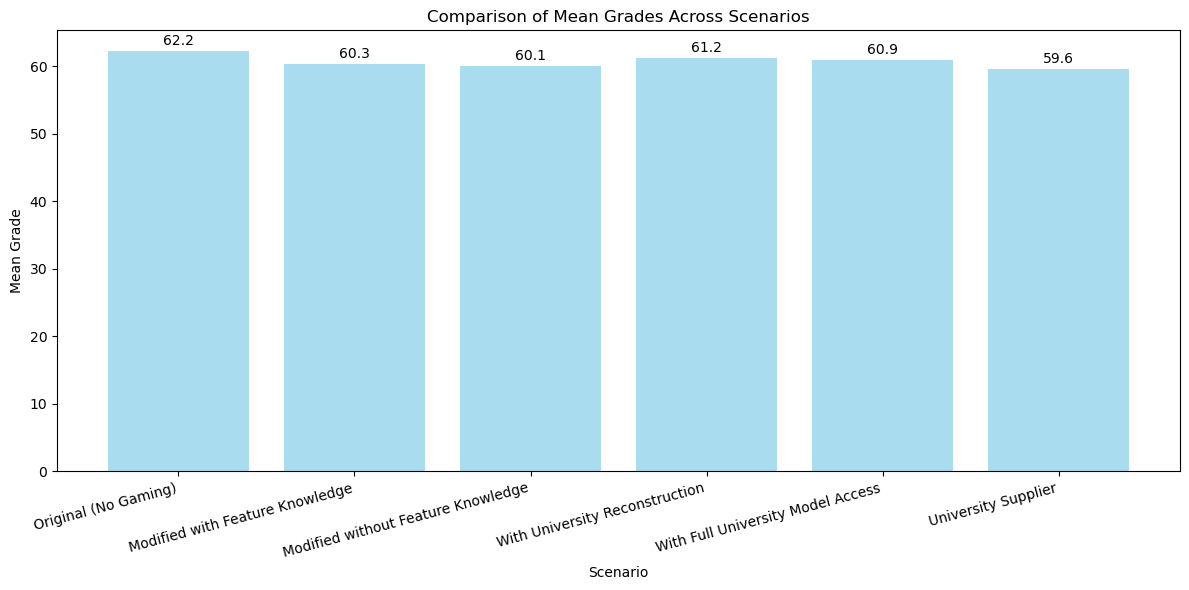

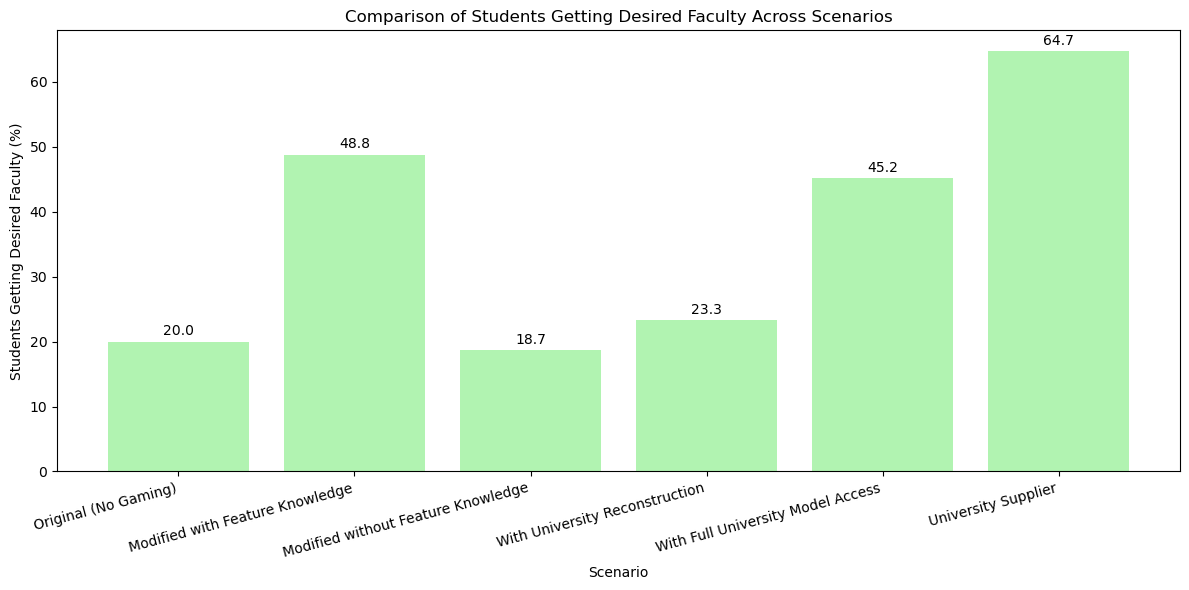

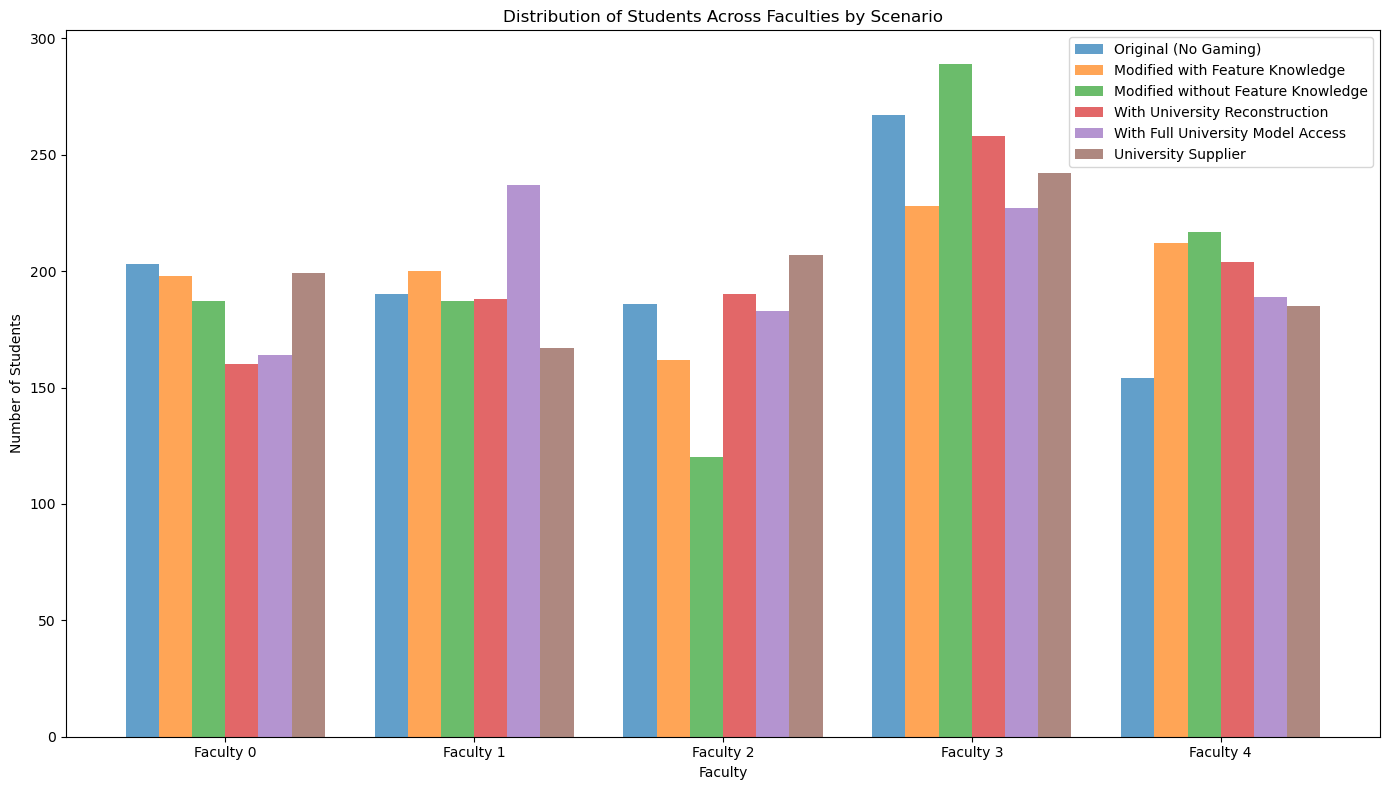

In [2]:
# Run the comprehensive experiment with all strategies
env, feature_cols, original_features, modified_features_dict, scenario_results = run_experiment(verbose=False)

## Feature Comparison Visualization

Compare how different strategies modify applicant features.

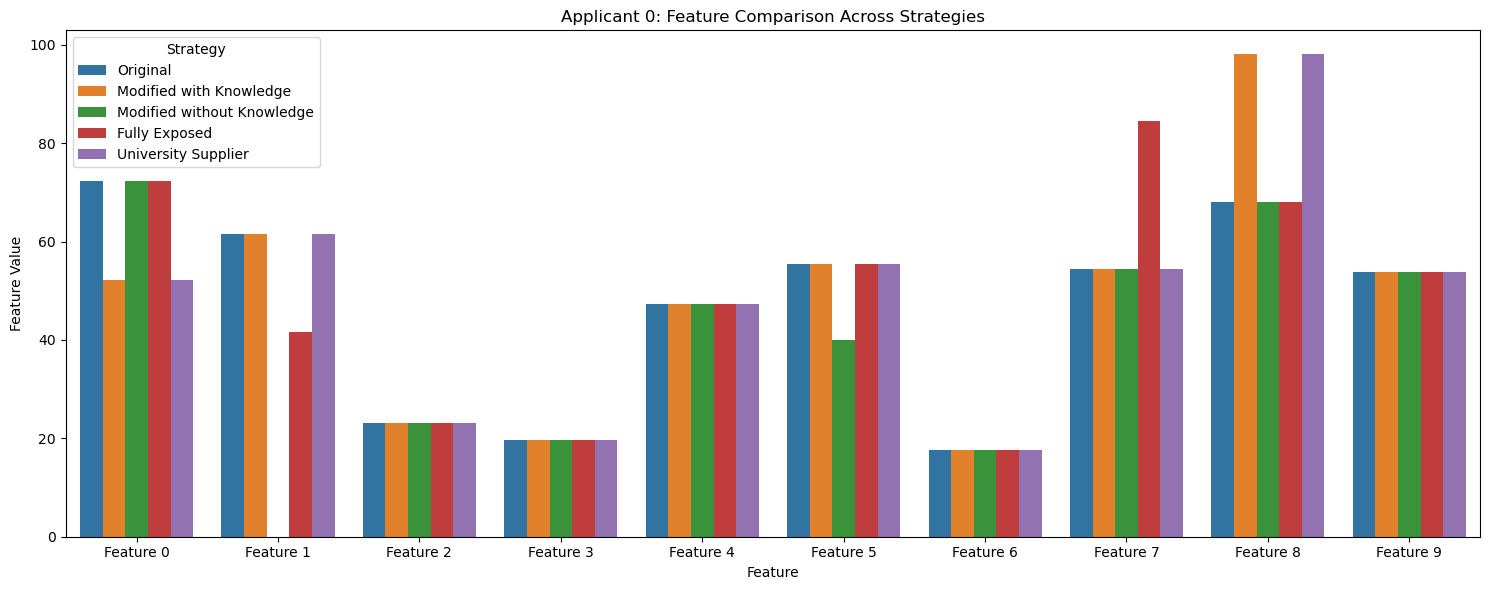

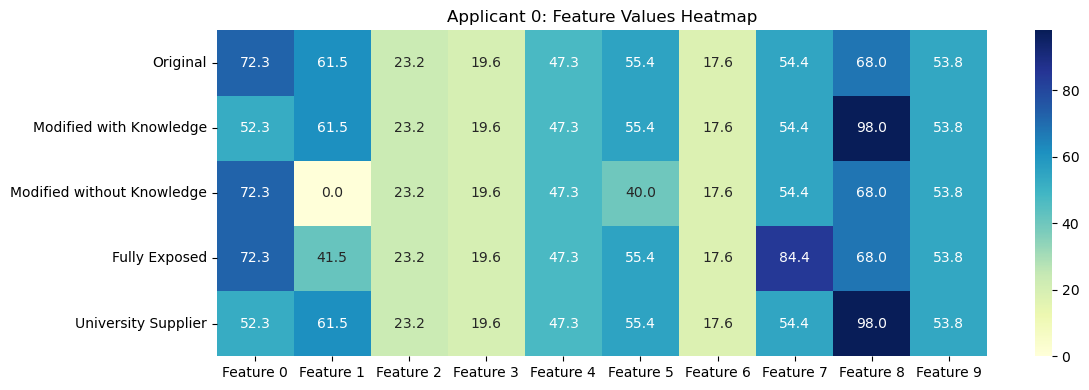

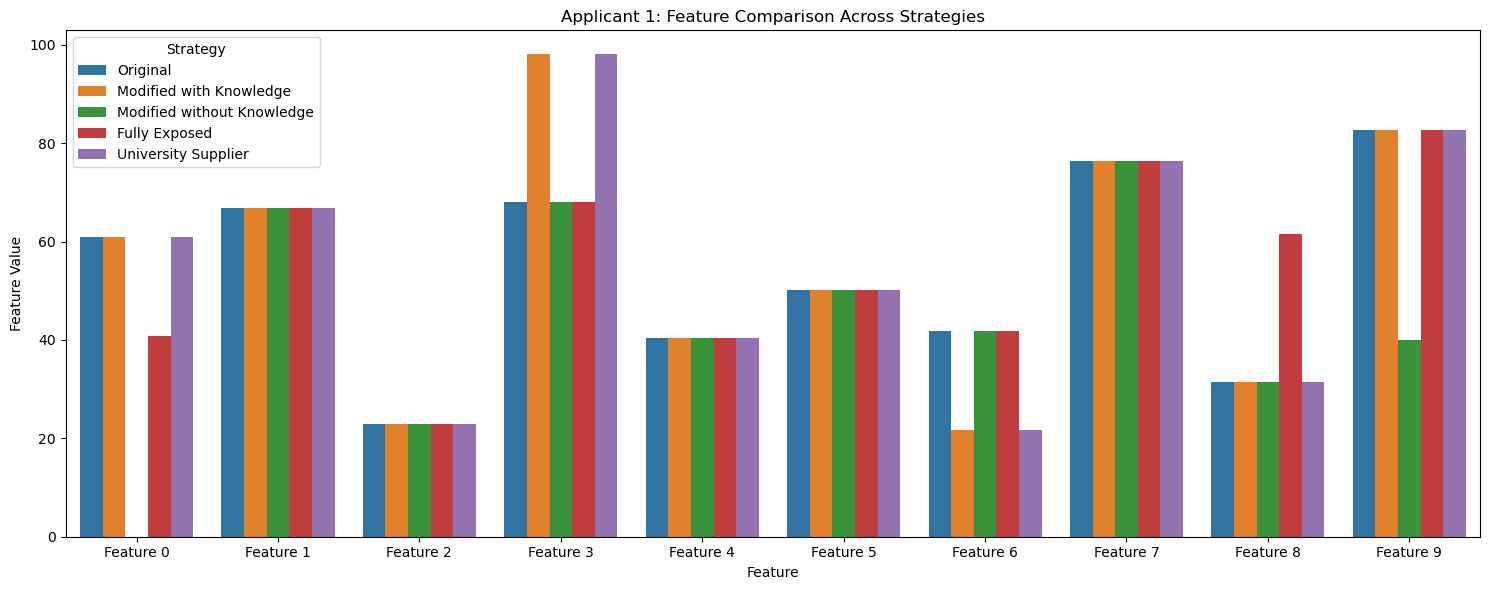

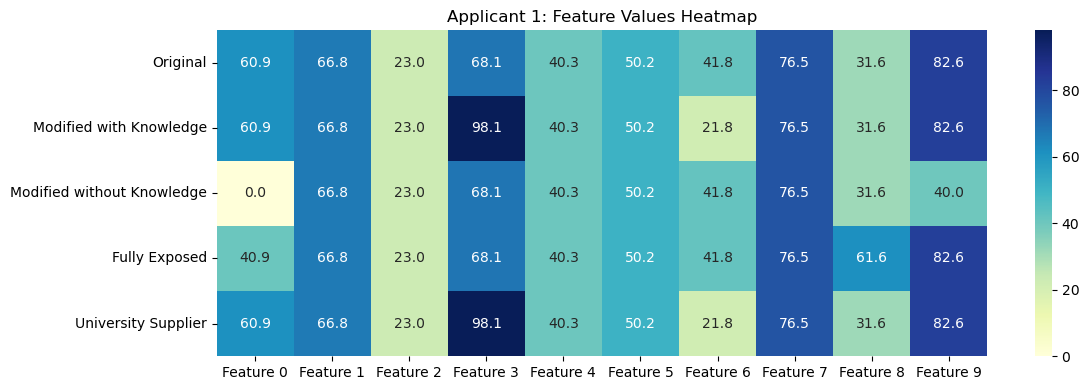

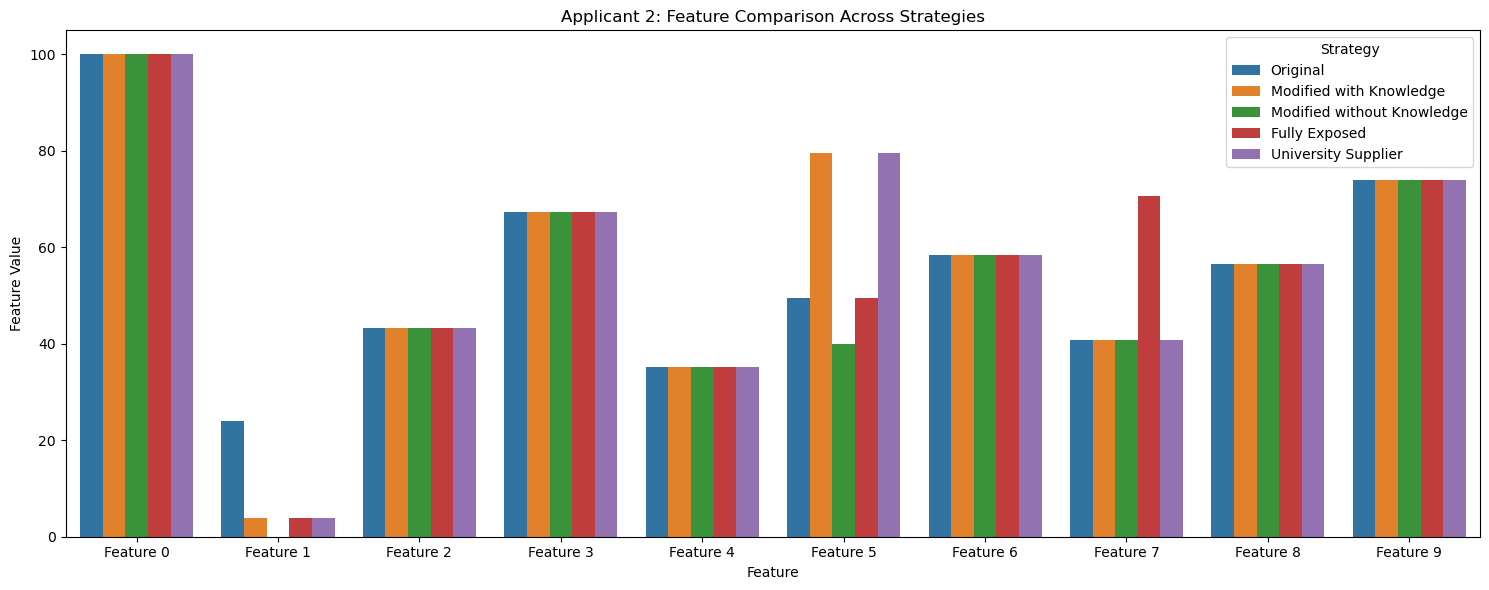

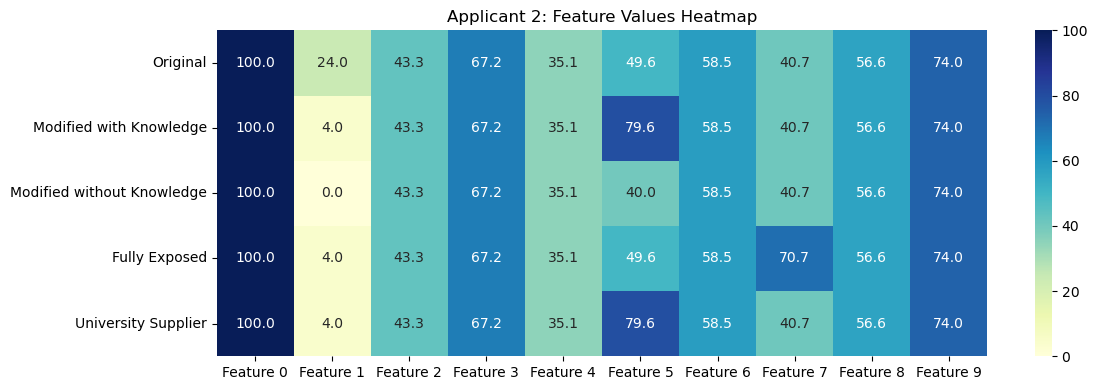

In [3]:
def visualize_feature_changes(original, modified_dict, sample_indices=[0, 1, 2], n_features=10):
    """Visualize how features change across different strategies for selected applicants"""
    # Get strategy names and ensure original is first
    strategies = ['Original'] + list(modified_dict.keys())
    
    # For each sample, create a visualization
    for idx in sample_indices:
        plt.figure(figsize=(15, 6))
        
        # Prepare data from each strategy
        all_features = [original[idx, :n_features]]
        for strategy in modified_dict.keys():
            all_features.append(modified_dict[strategy][idx, :n_features])
        
        # Create DataFrame for plotting
        df_data = []
        for i, strategy in enumerate(strategies):
            for j in range(n_features):
                df_data.append({
                    'Feature': f'Feature {j}',
                    'Value': all_features[i][j],
                    'Strategy': strategy
                })
        
        df = pd.DataFrame(df_data)
        
        # Create grouped bar plot
        ax = sns.barplot(data=df, x='Feature', y='Value', hue='Strategy')
        plt.title(f'Applicant {idx}: Feature Comparison Across Strategies')
        plt.ylabel('Feature Value')
        plt.legend(title='Strategy')
        plt.tight_layout()
        plt.show()
        
        # Create heatmap for easier comparison
        plt.figure(figsize=(12, len(strategies) * 0.8))
        heatmap_data = np.array(all_features)
        sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlGnBu',
                  xticklabels=[f'Feature {i}' for i in range(n_features)],
                  yticklabels=strategies)
        plt.title(f'Applicant {idx}: Feature Values Heatmap')
        plt.tight_layout()
        plt.show()

# Visualize feature changes for first 3 applicants
visualize_feature_changes(original_features, modified_features_dict)

## Explore Environment

Examine the environment setup (faculties, suppliers, etc.)

Faculty Utility Vectors:
Faculty 0 utility vector: [0.2111676  0.04529841 0.21558976 0.02852411 0.00743378 0.00743263
 0.20446295 0.04127044 0.20508299 0.03373733]
Faculty 1 utility vector: [0.03230668 0.00736547 0.01542564 0.01934441 0.02408112 0.22339703
 0.01054305 0.23155604 0.223932   0.21204856]
Faculty 2 utility vector: [0.21620425 0.02875322 0.22377294 0.00817184 0.22835527 0.00859001
 0.03560523 0.21398605 0.00980168 0.02675951]
Faculty 3 utility vector: [0.0474844  0.20247447 0.0135774  0.21440868 0.23923363 0.22743674
 0.02082865 0.01942565 0.01443774 0.00069264]
Faculty 4 utility vector: [0.01605715 0.00308423 0.01509072 0.21542308 0.03540484 0.03093809
 0.04305285 0.19948493 0.20389247 0.23757164]


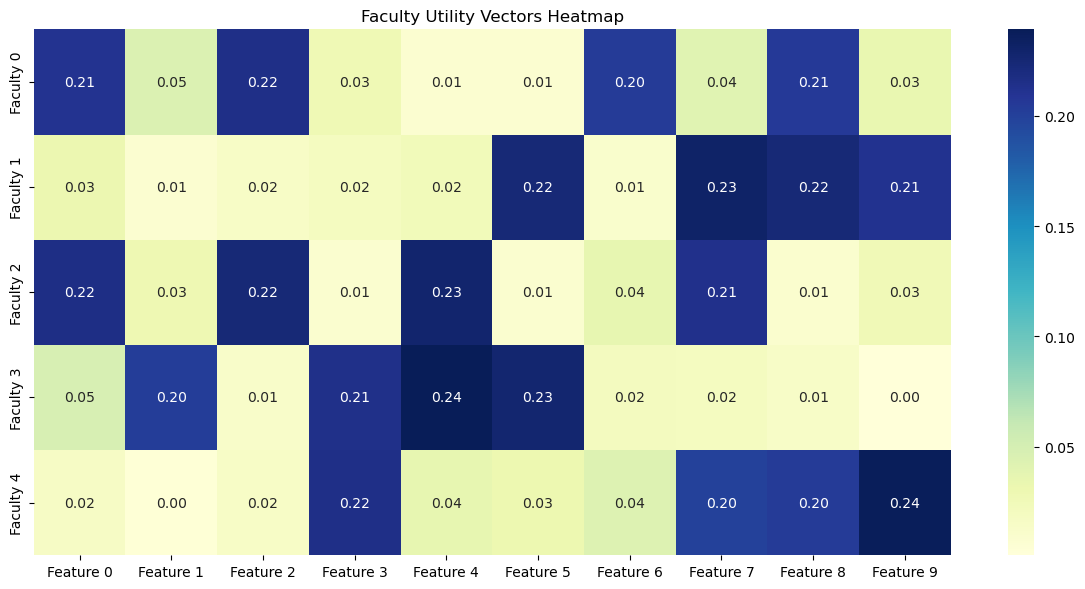

In [4]:
# Create an environment and examine its properties
# Print faculty information
print("Faculty Utility Vectors:")
for i, faculty in enumerate(env.faculties):
    print(f"Faculty {i} utility vector: {faculty.utility_vector}")
    
# Create a heatmap visualization of faculty utility vectors
utility_vectors = np.array([faculty.utility_vector for faculty in env.faculties])
plt.figure(figsize=(12, 6))
sns.heatmap(utility_vectors, cmap='YlGnBu', annot=True, fmt='.2f',
          xticklabels=[f'Feature {i}' for i in range(env.n_features)],
          yticklabels=[f'Faculty {i}' for i in range(env.n_faculties)])
plt.title('Faculty Utility Vectors Heatmap')
plt.tight_layout()
plt.show()


Sample Supplier Modification Vectors:
Supplier 0 modification vector: [  0  30   0   0   0   0   0   0   0 -20]
Supplier 1 modification vector: [-20   0   0   0   0   0   0   0  30   0]
Supplier 2 modification vector: [ 30   0 -20   0   0   0   0   0   0   0]
Supplier 3 modification vector: [  0  30 -20   0   0   0   0   0   0   0]
Supplier 4 modification vector: [  0   0   0   0   0   0   0  30   0 -20]


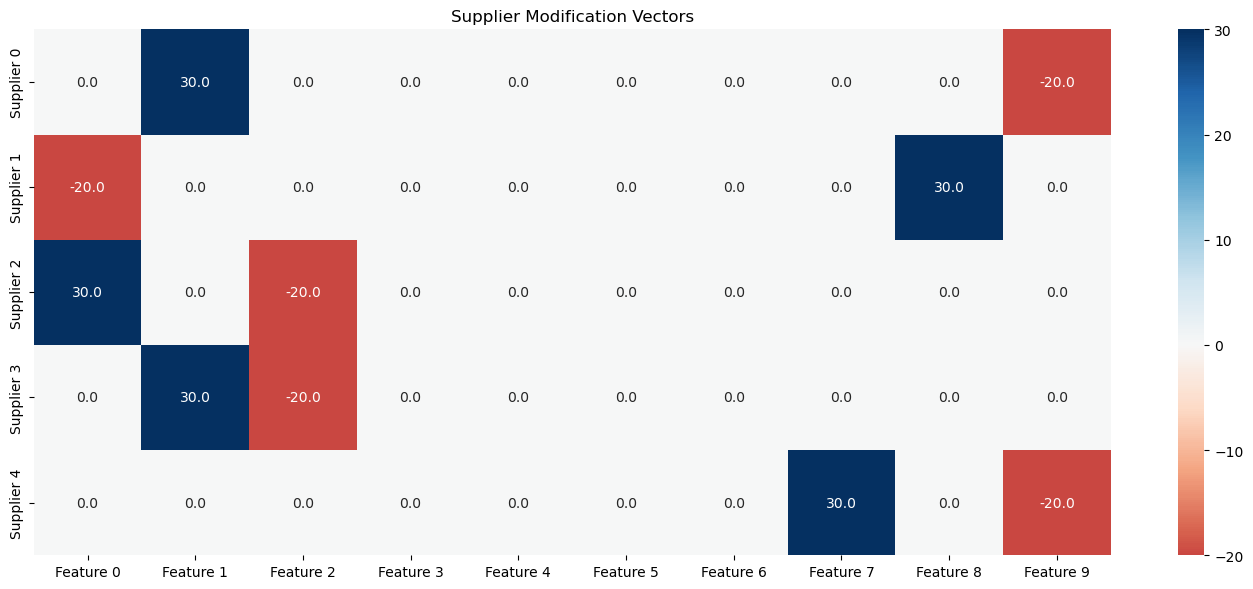

In [5]:
# Print some supplier information
print("\nSample Supplier Modification Vectors:")
n_suppliers_to_show = min(5, len(env.suppliers))
for i in range(n_suppliers_to_show):
    print(f"Supplier {i} modification vector: {env.suppliers[i].diff_vector}")

# Visualize supplier modification vectors
modification_vectors = np.array([env.suppliers[i].diff_vector for i in range(n_suppliers_to_show)])
plt.figure(figsize=(14, 6))
sns.heatmap(modification_vectors, cmap='RdBu', center=0, annot=True, fmt='.1f',
          xticklabels=[f'Feature {i}' for i in range(env.n_features)],
          yticklabels=[f'Supplier {i}' for i in range(n_suppliers_to_show)])
plt.title('Supplier Modification Vectors')
plt.tight_layout()
plt.show()

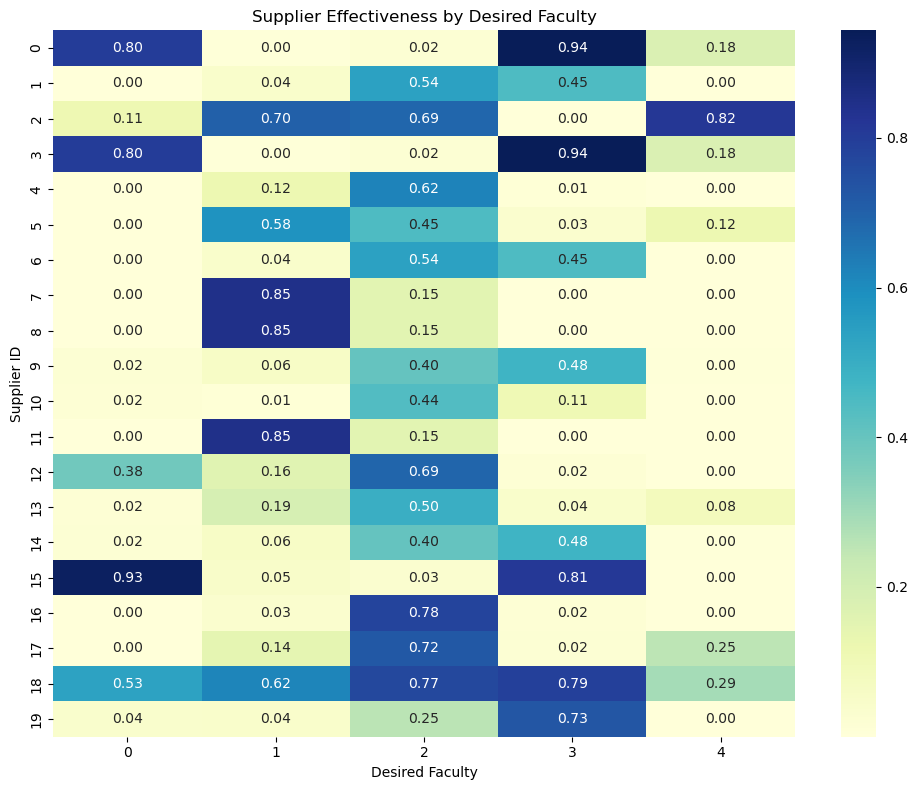

Best suppliers for each desired faculty:


,Desired Faculty,Supplier,Probability
15,0,15,0.927362
27,1,7,0.847712
56,2,16,0.780160
60,3,0,0.943582
82,4,2,0.817098


In [6]:
# Analyze which suppliers were most frequently chosen
def analyze_optimal_suppliers():
    """Create a test of all suppliers to see which ones perform best for different desired faculties"""
    test_env = UniversityEnvironment()
    test_features = np.ones((1, test_env.n_features)) * 50  # Standard features
    
    results = []
    for desired_faculty in range(test_env.n_faculties):
        best_probs = []
        best_suppliers = []
        
        # Train a simple model
        past_df = test_env.generate_past_applicants(1000)
        model = test_env.train_applicant_model(past_df)
        
        for i, supplier in enumerate(test_env.suppliers):
            # Apply supplier modifications
            modified = test_features + supplier.diff_vector
            modified = np.clip(modified, 0, 100)
            
            # Get probability of desired faculty
            model.eval()
            with torch.no_grad():
                probs = model(torch.FloatTensor(modified))
                prob = probs[0, desired_faculty].item()
            
            results.append({
                'Desired Faculty': desired_faculty,
                'Supplier': i,
                'Probability': prob,
                'Modification': supplier.diff_vector
            })
    
    # Convert to DataFrame
    df = pd.DataFrame(results)
    
    # Find best supplier for each faculty
    best_suppliers = df.loc[df.groupby('Desired Faculty')['Probability'].idxmax()]
    
    # Plot heatmap of probabilities
    pivot_df = df.pivot(index='Supplier', columns='Desired Faculty', values='Probability')
    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot_df, annot=True, fmt='.2f', cmap='YlGnBu')
    plt.title('Supplier Effectiveness by Desired Faculty')
    plt.xlabel('Desired Faculty')
    plt.ylabel('Supplier ID')
    plt.tight_layout()
    plt.show()
    
    # Display best suppliers
    print("Best suppliers for each desired faculty:")
    display(best_suppliers[['Desired Faculty', 'Supplier', 'Probability']])
    
    return df

# Analyze which suppliers work best for different faculties
supplier_analysis = analyze_optimal_suppliers()

## Results



Our experimental results across different scenarios reveal several key insights when looking at the total mean grades and the percentage of students assigned to their desired faculty:

1. **Base Scenario (Modified with Feature Knowledge)**
-  This is the scenario we will keep as the baseline for comparison.
- Moderate amount of information is exposed to the applicants, and the university is able to achieve a good balance between student satisfaction and system effectiveness.
- The university is able to achieve a total mean grade of <>, which is above the average of student's features without assigning them to a faculty. Given the fact that the faculty vector is normalized, this is a good result.
- There are <> faculties, which mean a random assignment will result in <>% of students getting their desired faculty. We see the number of students assigned to their desired faculty is <>, which is almost double the random assignment.

2. **Original Features (No Gaming)**
- The precentage of students assigned to their desired faculty is <>, which is almost the same as random assignment. This was to be expected as the students are not able to manipulate the system.
- The mean grade is <>, which is significatly higher than the base scenario, which means that the university is able to assign students to the correct faculty without the noise of the supplier. 
- This scenario showcase what happens when university has all the information and applicants are not strategic at all. In this case prediction is equivalent to recommendation! and we see in the base scenario which is closer to "real" that it doesn't perform as well as thought.

2. **Modified Without Feature Knowledge**
- Showcases strategic applicants that aren't exposed to critical information about their own features, and so aren't able to manipulate the system in a meaningful way for them.
- The precentage of students assigned to their faculty is <>, which is close to total random assignment.
- The mean grade is <> which is the lowest of all the scenarios.
- This is a lose-lose situation for the university as well as the applicants. It showcases the importance of the university to acknowledge the strategic behavior of the applicants and to expose them with information about their own features.


3. **Fully Exposed Supplier Scenario**
- This variation represents the case where the university provide the applicnts full access to it's most critical information (utility vector) and the applicants are able to perfectly predict the supplier's impact on the students.
This makes the universuty exposed to the biggest risk of applicants gaming the system.
- The precentage of students assigned to their faculty is <>, which matches the precentage of students assigned to their desired faculty in the base scenario (showing the applicant were able to manipulate the system fairly well in the base scenario).
- This results show the full potential of the applicants to manipulate the system and to achieve their desired faculty.
- The mean grade is <>, which is as low as the other scenarios where the applicants were able to manipulate the system.
- This scenario showcases the importance of the university to not expose the applicants with too much information, as this will give too much power to the applicants to manipulate the system.

4. **University Reconstruction Scenario**
- This scenario showcases the university's ability to reconstruct the applicants' features and to assign them to the correct faculty. It follows the intuition presented in the class, where we try to predict the applicants' gaming and then undo it.
- The precentage of students assigned to their faculty is <>, which is a bit higher than a random assignment.
- The mean grade is <>, which is in the middle between the base scenario and the original features scenario, suggesting a good balance between the university's ability to reconstruct the applicants' features and the applicants' ability to manipulate the system.

5. **University as Supplier Scenario**
- This scenario showcases the university's ability to act as a supplier and to help the applicants to achieve their desired faculty, as another option of a win-win situation.
- The precentage of students assigned to their faculty is <>, which is better than the other scenarios where the applicants were not able to get their desired faculty.
- The mean grade is <>, which is surprisingly low, suggesting that the university doesn't gain much from being a supplier. This might be due to the fact that the applicants who choose the university are the ones who are most likely to not get their desired faculty anyway.

## Conclusions

Looking at all this, we learned some interesting things:

1. **Information Matters**
When students know their actual abilities, they make better choices - even when trying to game the system. This is different from the simple accept/reject case we saw in class.

2. **It's Complicated**
Unlike a simple yes/no decision, having multiple faculties makes everything messier. What's "good" depends on what each student wants, and that makes it harder for universities to spot and prevent gaming.

3. **Fighting Gaming Might Not Be Worth It**
Traditional anti-gaming measures don't work as well here because it's hard to tell the difference between a student who's gaming the system and one who just really wants to study in a particular faculty.

4. **Working Together Might Be Better**
When the university tried to help students instead of fight them, things worked out better for everyone. Maybe the answer isn't to prevent gaming but to guide it in a helpful direction.

Looking ahead, we think universities might want to focus less on preventing gaming and more on finding ways to work with students to get good outcomes for everyone. It's not perfect, but it seems to work better than trying to outsmart each other.

Of course, this is just a simulation, and real life is way more complicated. But it gives us some ideas about how to think about these problems differently.

## Addressing our reasearch question

We have looked at different scenarios which various levels of information exposure to the applicants, and various levels of strategic behavior from the applicants and university.

We have seen a clear trade-off between the university's objective of maximizing the mean grade and the applicants' objective of maximizing their chance of getting their desired faculty.

Overall, we do see the existence of a "sweet spot": The lose-lose situation is when the university ignores the strategic nature of the applicants and don't expose them with information about their own features.
But when the applicants are fully exposed to the university's decision-making process, they are able to abuse the system to achieve their desired faculty and result in the lowest mean grade.

The best compromise we did see is in scenarios of shared information between university and applicants, and when the university acknowledges that prediction is not the same as recommendation, and the applicants are stragetic.
This was shown when university tries to reconstruct the applicants' features while sharing the information with the applicants and in turn getting their desired faculty information. 